# Training curves

Parse `training.csv` (stdout log from `train.py`) for train/val **latent MSE** by epoch.

Overlay `sweep.csv` (stdout from `select_checkpoint.py`) for **val volume RMSE** at snapshot epochs (every 10 epochs) on a second y-axis.

Exports **`training_curves.pdf`** (vector) for LaTeX — fonts match `newpxtext` (Palatino) when MiKTeX/TeX Live + `newpx` are installed (`text.usetex`); otherwise a Palatino-like serif fallback is used.

Saved C:\Users\Jesper\Tilburg University\Thesis\PointSDF_2\misc\training_curves.pdf


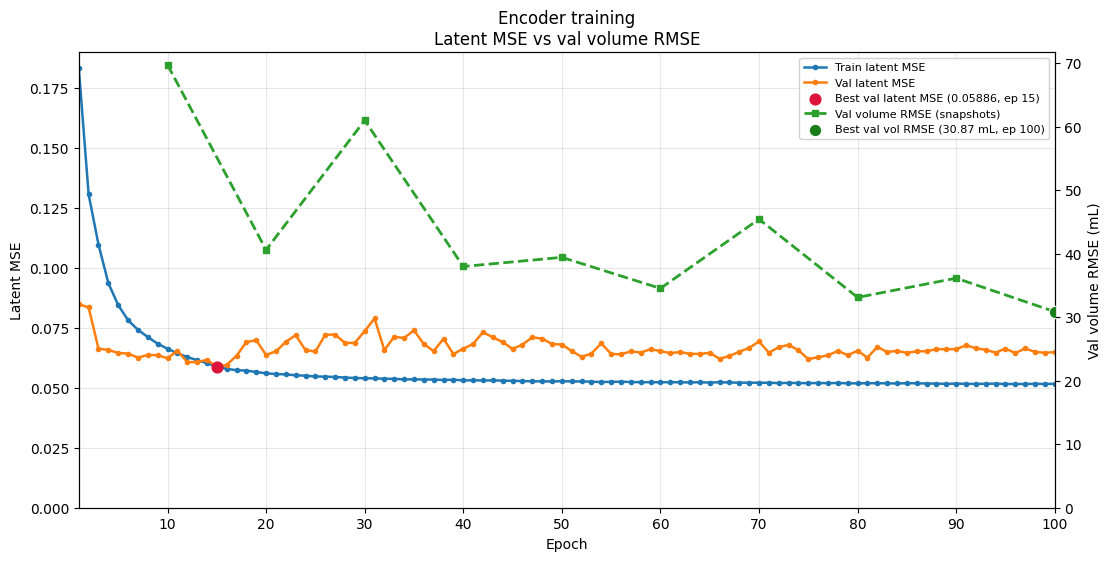

Latent MSE (training.csv): 100 epochs | final train=0.05171 | final val=0.06490 | best val=0.05886 @ epoch 15
Val volume (sweep.csv): 10 snapshots | best RMSE=30.87 mL @ epoch 100 | MAE=23.13 mL | R²=0.845
Note: best latent-MSE epoch (15) != best volume-RMSE epoch (100) — use select_checkpoint for deployment.


In [6]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd

# Match thesis fonts: newpxtext (Palatino) via LaTeX when available.
LATEX_PREAMBLE = r"""
\usepackage[T1]{fontenc}
\usepackage{newpxtext}
\usepackage[scaled=0.92]{helvet}
"""


def configure_thesis_fonts() -> str:
    """Use the same Palatino stack as the thesis (newpxtext); fall back if no LaTeX."""
    mpl.rcParams.update(
        {
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.unicode_minus": False,
        }
    )
    try:
        mpl.rcParams.update(
            {
                "text.usetex": True,
                "font.family": "serif",
                "text.latex.preamble": LATEX_PREAMBLE.strip(),
            }
        )
        fig = plt.figure(figsize=(0.1, 0.1))
        fig.text(0.5, 0.5, "test")
        fig.canvas.draw()
        plt.close(fig)
        return "LaTeX usetex (newpxtext / Palatino)"
    except Exception:
        mpl.rcParams.update(
            {
                "text.usetex": False,
                "font.family": "serif",
                "font.serif": [
                    "TeX Gyre Pagella",
                    "Palatino Linotype",
                    "Palatino",
                    "DejaVu Serif",
                ],
            }
        )
        return "Fallback serif (install MiKTeX + newpx for exact Palatino match)"


FONT_MODE = configure_thesis_fonts()
print(f"Plot fonts: {FONT_MODE}")

LOG_PATH = Path("training.csv")
SWEEP_PATH = Path("sweep.csv")
OUT_PDF = Path("training_curves.pdf")  # vector PDF for LaTeX \includegraphics[width=\linewidth]{...}
EPOCH_RE = re.compile(
    r"Epoch\s+(\d+)/\d+\s+\|\s+train\s+[\d.]+\s+\(mse=([\d.]+)\)\s+\|\s+val\s+[\d.]+\s+\(mse=([\d.]+)\)"
)
SWEEP_RE = re.compile(
    r"Epoch\s+(\d+)\s+\|\s+RMSE=([\d.]+)\s+mL\s+MAE=([\d.]+)\s+mL\s+R²=([\d.]+)"
)


def load_training_log(path: Path) -> pd.DataFrame:
    rows: list[dict[str, float | int]] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        m = EPOCH_RE.search(line)
        if not m:
            continue
        rows.append(
            {
                "epoch": int(m.group(1)),
                "train_mse": float(m.group(2)),
                "val_mse": float(m.group(3)),
            }
        )
    if not rows:
        raise ValueError(f"No epoch lines parsed from {path.resolve()}")
    return pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)


def load_sweep_log(path: Path) -> pd.DataFrame:
    rows: list[dict[str, float | int]] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        m = SWEEP_RE.search(line)
        if not m:
            continue
        rows.append(
            {
                "epoch": int(m.group(1)),
                "val_vol_rmse_ml": float(m.group(2)),
                "val_vol_mae_ml": float(m.group(3)),
                "val_vol_r2": float(m.group(4)),
            }
        )
    if not rows:
        raise ValueError(f"No checkpoint lines parsed from {path.resolve()}")
    return pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)


df = load_training_log(LOG_PATH)
best_mse_idx = df["val_mse"].idxmin()
best_mse = df.loc[best_mse_idx]

df_sweep = load_sweep_log(SWEEP_PATH)
best_vol_idx = df_sweep["val_vol_rmse_ml"].idxmin()
best_vol = df_sweep.loc[best_vol_idx]

fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
ax.plot(df["epoch"], df["train_mse"], marker="o", markersize=3, lw=1.8, label="Train latent MSE")
ax.plot(df["epoch"], df["val_mse"], marker="o", markersize=3, lw=1.8, label="Val latent MSE")
ax.scatter(
    [best_mse["epoch"]],
    [best_mse["val_mse"]],
    s=60,
    color="crimson",
    zorder=3,
    label=f"Best val latent MSE ({best_mse['val_mse']:.5f}, ep {int(best_mse['epoch'])})",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Latent MSE")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.set_xlim(df["epoch"].min(), df["epoch"].max())
ax.xaxis.set_major_locator(MultipleLocator(10))

ax2 = ax.twinx()
ax2.plot(
    df_sweep["epoch"],
    df_sweep["val_vol_rmse_ml"],
    color="#2ca02c",
    marker="s",
    markersize=5,
    lw=2.0,
    ls="--",
    label="Val volume RMSE (snapshots)",
)
ax2.scatter(
    [best_vol["epoch"]],
    [best_vol["val_vol_rmse_ml"]],
    s=80,
    color="#1a7f1a",
    edgecolors="white",
    linewidths=0.8,
    zorder=3,
    label=f"Best val vol RMSE ({best_vol['val_vol_rmse_ml']:.2f} mL, ep {int(best_vol['epoch'])})",
)
ax2.set_ylabel("Val volume RMSE (mL)")
ax2.set_ylim(bottom=0)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", framealpha=0.9, fontsize=8)

ax.set_title("Encoder training\nLatent MSE vs val volume RMSE")

fig.savefig(
    OUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)
print(f"Saved {OUT_PDF.resolve()} ({FONT_MODE})")

plt.show()

print(
    f"Latent MSE ({LOG_PATH.name}): {len(df)} epochs | "
    f"final train={df['train_mse'].iloc[-1]:.5f} | final val={df['val_mse'].iloc[-1]:.5f} | "
    f"best val={best_mse['val_mse']:.5f} @ epoch {int(best_mse['epoch'])}"
)
print(
    f"Val volume ({SWEEP_PATH.name}): {len(df_sweep)} snapshots | "
    f"best RMSE={best_vol['val_vol_rmse_ml']:.2f} mL @ epoch {int(best_vol['epoch'])} | "
    f"MAE={best_vol['val_vol_mae_ml']:.2f} mL | R²={best_vol['val_vol_r2']:.3f}"
)
if int(best_mse["epoch"]) != int(best_vol["epoch"]):
    print(
        f"Note: best latent-MSE epoch ({int(best_mse['epoch'])}) != "
        f"best volume-RMSE epoch ({int(best_vol['epoch'])}) — use select_checkpoint for deployment."
    )